# Discrétisation de fonctions mathématiques

## Qu'est-ce que la discrétisation ?

En mathématiques, une fonction ($f(x)$) est souvent définie sur un **intervalle continu**.  
En informatique, on ne peut travailler, le plus souvent, qu'avec un nombre **fini** de valeurs.

La **discrétisation** consiste à représenter une fonction continue par un ensemble **fini ($n$) de points** :

$$
\{x_1, f(x_1)\}, \{x_2, f(x_2)\} \dots \{x_n, f(x_n)\}
$$

où les ordonnées $x_i$ sont répartis uniformément sur l'intervalle $[a, b]$ avec un pas :

$$
p = \frac{b - a}{n}
$$

Pour vous en rendre compte, on va représenter graphiquement la fonction $sin$ sur l'intervalle $[0, 4\pi]$ (c'est-à-dire 2 tours).

Chargeons d'abord la bibliothèque `matplotlib` :

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

Créons une fonction qui :

- Définit les abscisses et les ordonnées sous forme de 2 listes.
- Uilise le module `math` de Python qui donne accès à la fonction $sin$ et à la constante $\pi$.
- Crée le graphique de $sin(x)$ en fonction de $x$

In [23]:
import math

def discretise_sin(a, b, n):
    p = (b - a) / n
    abscisses = []
    ordonnees = []
    for i in range(n):
        x = p * i
        y = math.sin(x)
        abscisses.append(x)
        ordonnees.append(y)
    fig, ax = plt.subplots()
    ax.plot(abscisses, ordonnees, color="blue")
    ax.set_xlabel("x")
    ax.set_ylabel("sin(x)")
    ax.set_title(f"sin(x) en fonction de x pour {n} points")
    plt.show()

Affichons la discrétisation de la fonction $sin$ entre $0$ et $4 \pi$ pour 10 points :

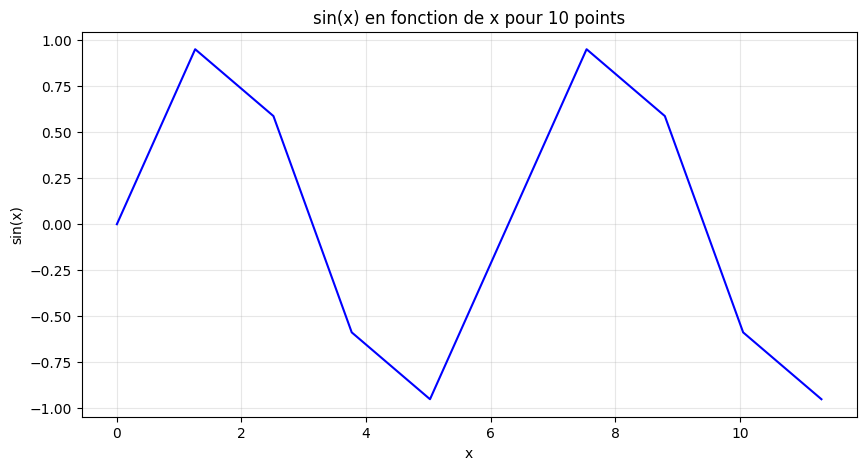

In [24]:
discretise_sin(0, 4 * math.pi, 10)

Et la même chose pour 100 points :

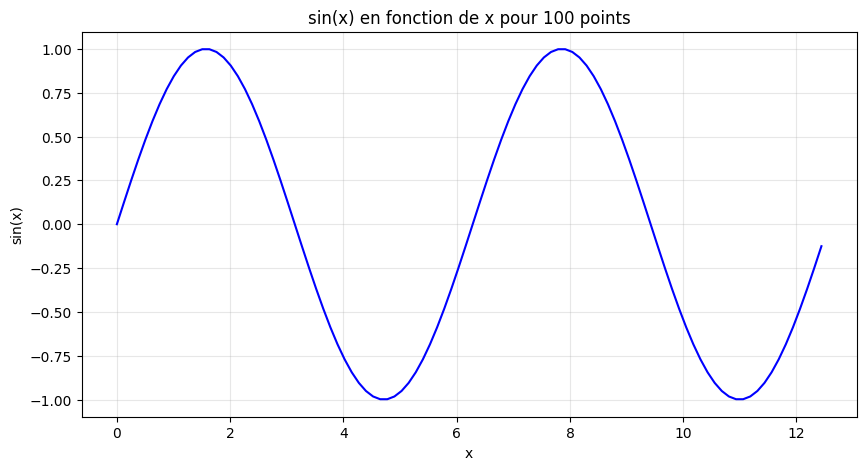

In [25]:
discretise_sin(0, 4 * math.pi, 100)

## 2.2 Application : Intégration Numérique

La discrétisation permet d'**approcher une intégrale** par la méthode des **rectangles** ou des **trapèzes**.

### Méthode des rectangles :
$$\int_a^b f(x)\,dx \approx h \sum_{i=0}^{n-1} f(x_i), \quad h = \frac{b-a}{n}$$

### Méthode des trapèzes :
$$\int_a^b f(x)\,dx \approx \frac{h}{2} \left[ f(x_0) + 2\sum_{i=1}^{n-1} f(x_i) + f(x_n) \right]$$

In [9]:
# ============================================================
# EXEMPLE 8 : Intégration numérique
# ============================================================

def integrale_rectangles(f, a, b, n):
    """Intégrale par la méthode des rectangles."""
    x, y = discretiser(f, a, b, n)
    h = (b - a) / n
    return h * np.sum(y[:-1])

def integrale_trapezes(f, a, b, n):
    """Intégrale par la méthode des trapèzes."""
    x, y = discretiser(f, a, b, n)
    h = (b - a) / n
    return h * (y[0]/2 + np.sum(y[1:-1]) + y[-1]/2)

# Test : intégrale de sin(x) sur [0, π] = 2 (valeur exacte)
f = lambda x: np.sin(x)
valeur_exacte = 2.0

print(f"Valeur exacte : {valeur_exacte}")
print("-" * 45)

for n in [10, 100, 1000, 10000]:
    rect = integrale_rectangles(f, 0, np.pi, n)
    trap = integrale_trapezes(f, 0, np.pi, n)
    print(f"n={n:6d} | Rectangles: {rect:.8f} | Trapèzes: {trap:.8f}")

Valeur exacte : 2.0
---------------------------------------------
n=    10 | Rectangles: 1.78168573 | Trapèzes: 1.78168573
n=   100 | Rectangles: 1.97983384 | Trapèzes: 1.97983384
n=  1000 | Rectangles: 1.99799835 | Trapèzes: 1.99799835
n= 10000 | Rectangles: 1.99979998 | Trapèzes: 1.99979998


## 2.3 Application : Dérivée Numérique

On peut approcher la **dérivée** d'une fonction discrétisée par la **différence finie** :

$$f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{h}$$

ou la formule **centrée** (plus précise) :

$$f'(x_i) \approx \frac{f(x_{i+1}) - f(x_{i-1})}{2h}$$

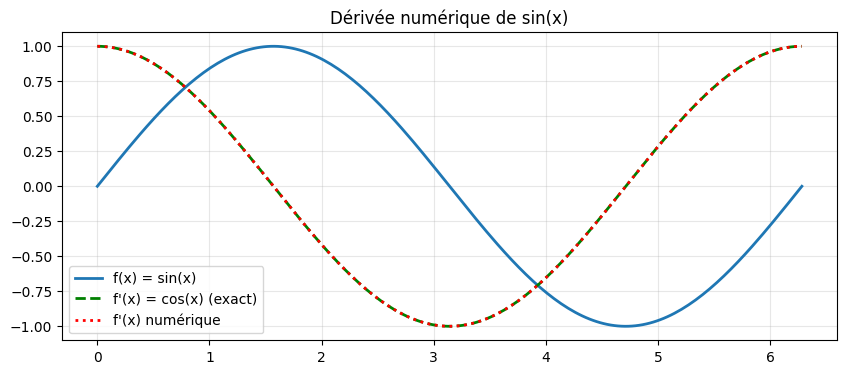

Erreur maximale : 1.66e-04


In [10]:
# ============================================================
# EXEMPLE 9 : Dérivée numérique par différences finies
# ============================================================

def derivee_numerique(f, a, b, n):
    """
    Calcule la dérivée numérique par différences finies centrées.
    """
    x, y = discretiser(f, a, b, n)
    h = (b - a) / (n - 1)
    dy = np.gradient(y, h)  # Différences finies centrées (numpy)
    return x, dy

# Test : dérivée de sin(x) = cos(x)
f = lambda x: np.sin(x)
x, df_num = derivee_numerique(f, 0, 2*np.pi, 200)

plt.figure(figsize=(10, 4))
plt.plot(x, np.sin(x), label="f(x) = sin(x)", linewidth=2)
plt.plot(x, np.cos(x), 'g--', label="f'(x) = cos(x) (exact)", linewidth=2)
plt.plot(x, df_num, 'r:', label="f'(x) numérique", linewidth=2)
plt.title("Dérivée numérique de sin(x)")
plt.legend()
plt.show()

# Erreur maximale
erreur = np.max(np.abs(df_num - np.cos(x)))
print(f"Erreur maximale : {erreur:.2e}")

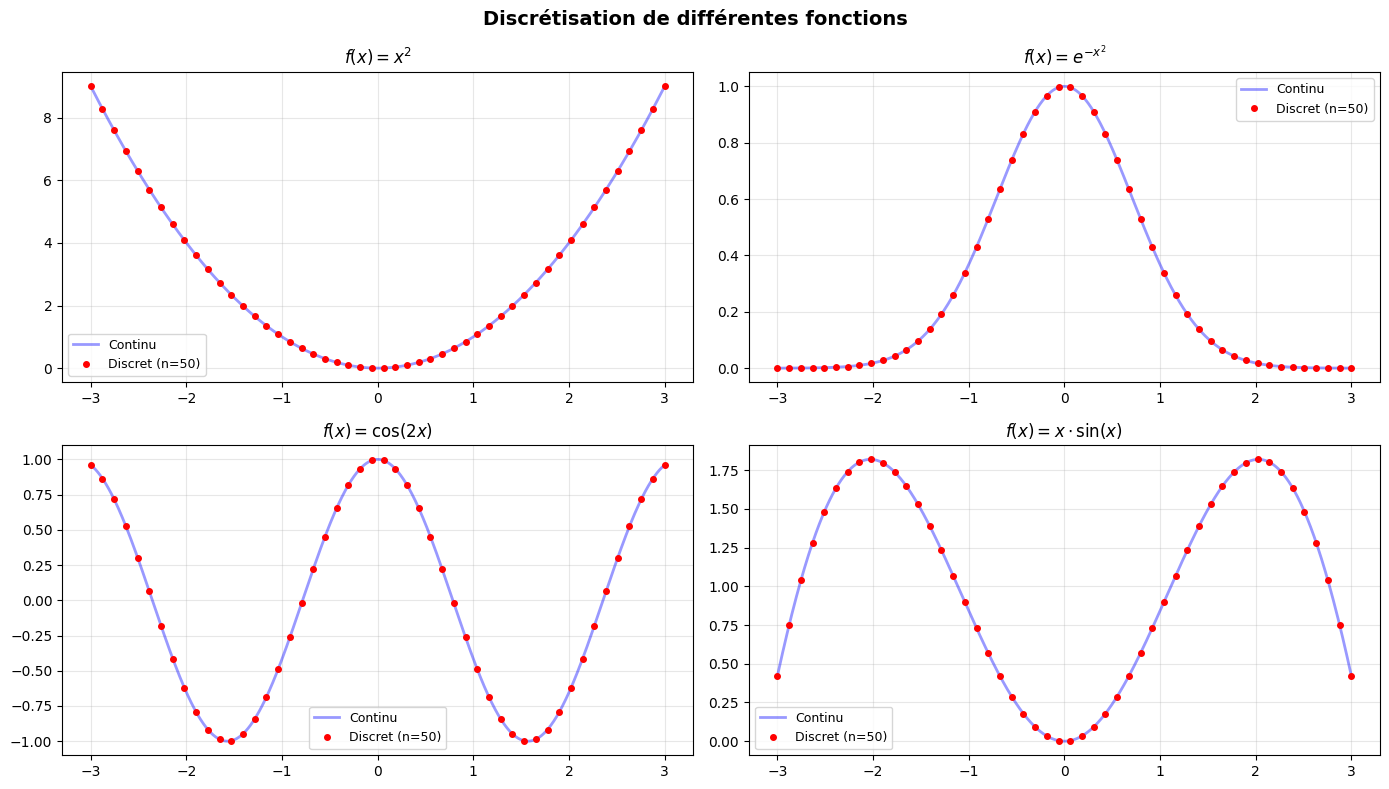

In [11]:
# ============================================================
# EXEMPLE 10 : Discrétisation de plusieurs fonctions
# ============================================================

fonctions = {
    r"$f(x) = x^2$":        lambda x: x**2,
    r"$f(x) = e^{-x^2}$":   lambda x: np.exp(-x**2),
    r"$f(x) = \cos(2x)$":   lambda x: np.cos(2*x),
    r"$f(x) = x \cdot \sin(x)$": lambda x: x * np.sin(x),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (nom, f) in zip(axes, fonctions.items()):
    a, b, n = -3, 3, 50
    x_cont = np.linspace(a, b, 1000)
    x_disc, y_disc = discretiser(f, a, b, n)

    ax.plot(x_cont, f(x_cont), 'b-', alpha=0.4, linewidth=2, label="Continu")
    ax.plot(x_disc, y_disc, 'ro', markersize=4, label=f"Discret (n={n})")
    ax.set_title(nom, fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle("Discrétisation de différentes fonctions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏋️ Exercices — Partie 2 : Discrétisation

### Exercice 5
Discrétise la fonction \\( f(x) = x^3 - 3x \\) sur \\([-2, 2]\\) avec \\(n = 20\\) points.  
Affiche le graphe avec la courbe continue en bleu et les points discrets en rouge.

### Exercice 6
Calcule numériquement l'intégrale de \\( f(x) = e^{-x^2} \\) sur \\([-3, 3]\\) avec la méthode des trapèzes.  
Compare avec la valeur approximée \\( \sqrt{\pi} \approx 1.7725 \\).

### Exercice 7
Calcule la dérivée numérique de \\( f(x) = x^3 \\) sur \\([-2, 2]\\).  
Compare avec la dérivée exacte \\( f'(x) = 3x^2 \\).

### Exercice 8 ⭐ (Avancé)
Écris une fonction `erreur_integration(f, a, b, exacte)` qui trace l'erreur de la méthode des trapèzes  
en fonction du nombre de points \\(n\\) (de 5 à 500).  
Teste-la avec \\( \int_0^\pi \sin(x)\,dx = 2 \\).


=== Exercice 5 ===


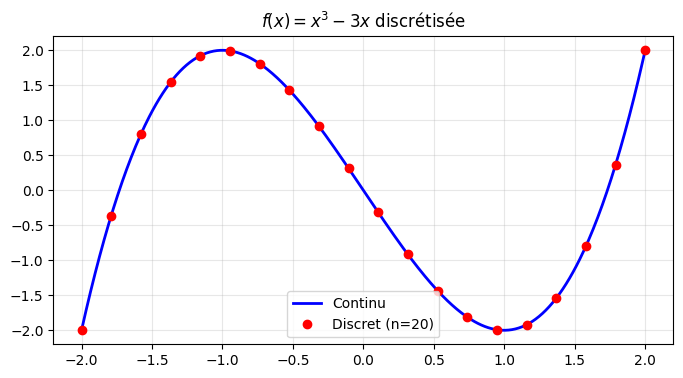


=== Exercice 6 ===
Intégrale numérique : 1.770642
√π                  : 1.772454
Erreur              : 1.81e-03

=== Exercice 7 ===


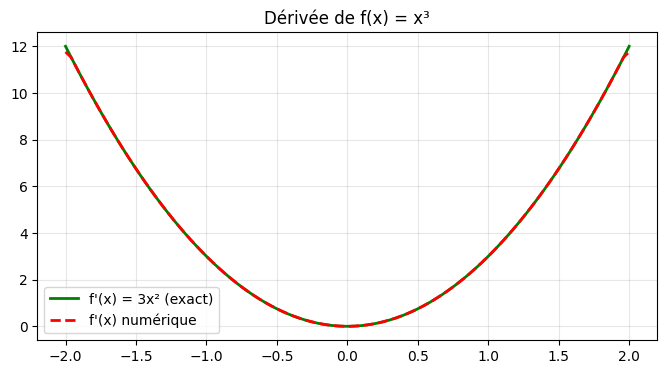

Erreur maximale : 2.41e-01

=== Exercice 8 ===


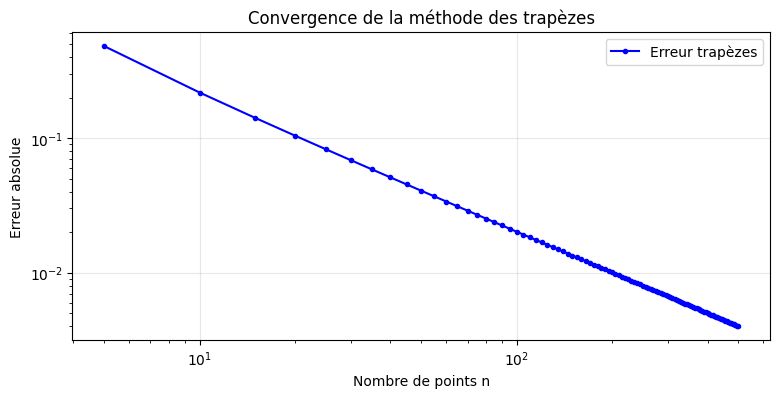

(array([  5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,
         70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125, 130,
        135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195,
        200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260,
        265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325,
        330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390,
        395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455,
        460, 465, 470, 475, 480, 485, 490, 495, 500]),
 [np.float64(0.48310488165036825),
  np.float64(0.218314269905165),
  np.float64(0.14117293446859724),
  np.float64(0.10433074759581529),
  np.float64(0.08274234002820902),
  np.float64(0.06855776539513014),
  np.float64(0.058525351412506366),
  np.float64(0.05105455896858291),
  np.float64(0.04527528982152962),
  np.float64(0.040671447662418814),
  np.float64(0.03691751746333316),
  np.float64(0.03379802593301284),
  np.float64(0

In [12]:
# ============================================================
# ✅ CORRECTIONS — Exercices Partie 2
# ============================================================

# --- Exercice 5 ---
print("=== Exercice 5 ===")
f5 = lambda x: x**3 - 3*x
x_disc, y_disc = discretiser(f5, -2, 2, 20)
x_cont = np.linspace(-2, 2, 500)

plt.figure(figsize=(8, 4))
plt.plot(x_cont, f5(x_cont), 'b-', linewidth=2, label="Continu")
plt.plot(x_disc, y_disc, 'ro', markersize=6, label="Discret (n=20)")
plt.title(r"$f(x) = x^3 - 3x$ discrétisée")
plt.legend()
plt.show()

# --- Exercice 6 ---
print("\n=== Exercice 6 ===")
f6 = lambda x: np.exp(-x**2)
resultat = integrale_trapezes(f6, -3, 3, 1000)
print(f"Intégrale numérique : {resultat:.6f}")
print(f"√π                  : {np.sqrt(np.pi):.6f}")
print(f"Erreur              : {abs(resultat - np.sqrt(np.pi)):.2e}")

# --- Exercice 7 ---
print("\n=== Exercice 7 ===")
f7 = lambda x: x**3
x7, df7_num = derivee_numerique(f7, -2, 2, 100)
df7_exact = 3 * x7**2

plt.figure(figsize=(8, 4))
plt.plot(x7, df7_exact, 'g-', linewidth=2, label="f'(x) = 3x² (exact)")
plt.plot(x7, df7_num, 'r--', linewidth=2, label="f'(x) numérique")
plt.title("Dérivée de f(x) = x³")
plt.legend()
plt.show()

erreur7 = np.max(np.abs(df7_num - df7_exact))
print(f"Erreur maximale : {erreur7:.2e}")

# --- Exercice 8 ---
print("\n=== Exercice 8 ===")

def erreur_integration(f, a, b, exacte, n_max=500):
    """Trace l'erreur de la méthode des trapèzes en fonction de n."""
    ns = np.arange(5, n_max + 1, 5)
    erreurs = [abs(integrale_trapezes(f, a, b, n) - exacte) for n in ns]
    
    plt.figure(figsize=(9, 4))
    plt.loglog(ns, erreurs, 'b-o', markersize=3, label="Erreur trapèzes")
    plt.xlabel("Nombre de points n")
    plt.ylabel("Erreur absolue")
    plt.title("Convergence de la méthode des trapèzes")
    plt.legend()
    plt.show()
    return ns, erreurs

f8 = lambda x: np.sin(x)
erreur_integration(f8, 0, np.pi, 2.0)